In [1]:
%pip install -Uq pandas adjdatatools scikit-learn kagglehub seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

df = pd.read_csv(path + "/healthcare-dataset-stroke-data.csv")
df.head()

/home/mike-pech/Documents/masters-theory/ML/Practice/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Бинарная классификация вероятности инсульта

Датасет содержит данные о здоровье людей и факт перенесённого инсульта (последняя колонка 0 — нет, 1 — да)

## 0. Предобработка

Так как в датасете уже есть классы, требуется только преобразовать данные в числовой вид и нормализовать их

In [3]:
# ID пациента не даёт данных для классификации
df = df.drop(columns=["id"])
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [5]:
# Дропаем NaN в колонке BMI
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4909 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4909 non-null   object 
 1   age                4909 non-null   float64
 2   hypertension       4909 non-null   int64  
 3   heart_disease      4909 non-null   int64  
 4   ever_married       4909 non-null   object 
 5   work_type          4909 non-null   object 
 6   Residence_type     4909 non-null   object 
 7   avg_glucose_level  4909 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     4909 non-null   object 
 10  stroke             4909 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 460.2+ KB


### Для задачи регрессии конвертируем текстовые признаки в числа

In [6]:
for column in df.columns:
    print("\n" + column + "\n\t")
    print(df[column].unique())
    print("-"*40)


gender
	
['Male' 'Female' 'Other']
----------------------------------------

age
	
[6.70e+01 8.00e+01 4.90e+01 7.90e+01 8.10e+01 7.40e+01 6.90e+01 7.80e+01
 6.10e+01 5.40e+01 5.00e+01 6.40e+01 7.50e+01 6.00e+01 7.10e+01 5.20e+01
 8.20e+01 6.50e+01 5.70e+01 4.20e+01 4.80e+01 7.20e+01 5.80e+01 7.60e+01
 3.90e+01 7.70e+01 6.30e+01 7.30e+01 5.60e+01 4.50e+01 7.00e+01 5.90e+01
 6.60e+01 4.30e+01 6.80e+01 4.70e+01 5.30e+01 3.80e+01 5.50e+01 4.60e+01
 3.20e+01 5.10e+01 1.40e+01 3.00e+00 8.00e+00 3.70e+01 4.00e+01 3.50e+01
 2.00e+01 4.40e+01 2.50e+01 2.70e+01 2.30e+01 1.70e+01 1.30e+01 4.00e+00
 1.60e+01 2.20e+01 3.00e+01 2.90e+01 1.10e+01 2.10e+01 1.80e+01 3.30e+01
 2.40e+01 3.60e+01 6.40e-01 3.40e+01 4.10e+01 8.80e-01 5.00e+00 2.60e+01
 3.10e+01 7.00e+00 1.20e+01 6.20e+01 2.00e+00 9.00e+00 1.50e+01 2.80e+01
 1.00e+01 1.80e+00 3.20e-01 1.08e+00 1.90e+01 6.00e+00 1.16e+00 1.00e+00
 1.40e+00 1.72e+00 2.40e-01 1.64e+00 1.56e+00 7.20e-01 1.88e+00 1.24e+00
 8.00e-01 4.00e-01 8.00e-02 1.48e+00 5.6

In [7]:
# Helper-функция
def integerize(column):
    replacements = {}
    i = 0
    for attribute in column.unique():
        replacements.update({attribute: i})
        i += 1
    print(replacements)
    return column.map(replacements)

In [8]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [9]:
to_replace = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

for column in to_replace:
    df[column] = integerize(df[column])

df.head(15)

{'Male': 0, 'Female': 1, 'Other': 2}
{'Yes': 0, 'No': 1}
{'Private': 0, 'Self-employed': 1, 'Govt_job': 2, 'children': 3, 'Never_worked': 4}
{'Urban': 0, 'Rural': 1}
{'formerly smoked': 0, 'never smoked': 1, 'smokes': 2, 'Unknown': 3}


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,0,0,0,228.69,36.6,0,1
2,0,80.0,0,1,0,0,1,105.92,32.5,1,1
3,1,49.0,0,0,0,0,0,171.23,34.4,2,1
4,1,79.0,1,0,0,1,1,174.12,24.0,1,1
5,0,81.0,0,0,0,0,0,186.21,29.0,0,1
6,0,74.0,1,1,0,0,1,70.09,27.4,1,1
7,1,69.0,0,0,1,0,0,94.39,22.8,1,1
9,1,78.0,0,0,0,0,0,58.57,24.2,3,1
10,1,81.0,1,0,0,0,1,80.43,29.7,1,1
11,1,61.0,0,1,0,2,1,120.46,36.8,2,1


### Нормализуем числа с учётом масштаба датасета

In [10]:
# Нормализация
from adjdatatools.preprocessing import AdjustedScaler

scaler = AdjustedScaler()
scaler.fit(df)
normalized_df = scaler.transform(df)
normalized_df.head(15)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,-1.0,0.280762,0.0,1.0,0.0,0.00,0.0,0.743448,0.221932,-0.5,1.0
2,-1.0,0.439453,0.0,1.0,0.0,0.00,1.0,0.077270,0.114883,0.0,1.0
3,0.0,0.061035,0.0,0.0,0.0,0.00,0.0,0.431657,0.164491,0.5,1.0
4,0.0,0.427246,1.0,0.0,0.0,0.25,1.0,0.447338,-0.107050,0.0,1.0
5,-1.0,0.451660,0.0,0.0,0.0,0.00,0.0,0.512942,0.023499,-0.5,1.0
6,-1.0,0.366211,1.0,1.0,0.0,0.00,1.0,-0.117152,-0.018277,0.0,1.0
7,0.0,0.305176,0.0,0.0,1.0,0.00,0.0,0.014705,-0.138381,0.0,1.0
9,0.0,0.415039,0.0,0.0,0.0,0.00,0.0,-0.179662,-0.101828,1.0,1.0
10,0.0,0.451660,1.0,0.0,0.0,0.00,1.0,-0.061045,0.041775,0.0,1.0
11,0.0,0.207520,0.0,1.0,0.0,0.50,1.0,0.156167,0.227154,0.5,1.0


## Линейная регрессия

Для задачи регрессии будем предсказывать индекс массы тела, т.к. основной параметр (инсульт) представлен как факт (0 или 1)

In [11]:
# Разбиваем на тренировочный и тестовый
from sklearn.model_selection import train_test_split

x, y = df.drop(columns="bmi"), df["bmi"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3
)

In [12]:
import numpy as np

### Без регуляризации

In [13]:
class MatrixLinearRegression:

    def fit(self, X, y):
        X = np.insert(X, 0, 1, axis=1)   # вектор единиц для B0
        XT_X_inv = np.linalg.inv(X.T @ X)   # (X.T * X) ** (-1)
        weights = np.linalg.multi_dot([XT_X_inv, X.T, y])   # XT_X_inv * X.T * y — веса B^
        self.bias, self.weights = weights[0], weights[1:]

    def predict(self, x_test):
        return x_test @ self.weights + self.bias

In [14]:
mat_lr = MatrixLinearRegression()
mat_lr.fit(x_train, y_train)

result = mat_lr.predict(x_test)

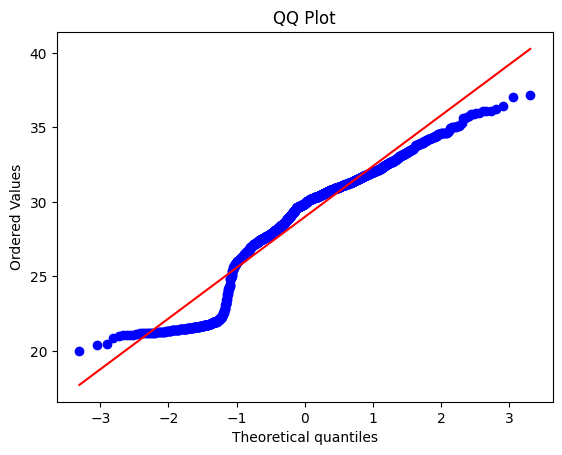

In [15]:
from scipy import stats as scs
import matplotlib.pyplot as plt

scs.probplot(result, dist='norm', plot=plt)
plt.title('QQ Plot')
plt.show()

##### График приближен к прямой главного тренда

Распределение результатов предсказаний близко к нормальному

In [16]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_test, result)

52.002589016923515

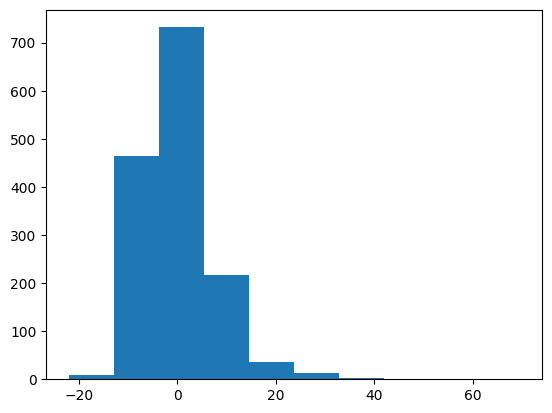

In [17]:
residual = y_test - result
plt.hist(residual)
plt.show()

### Ошибки редки, но нужно проверить на переобучение другим разделением

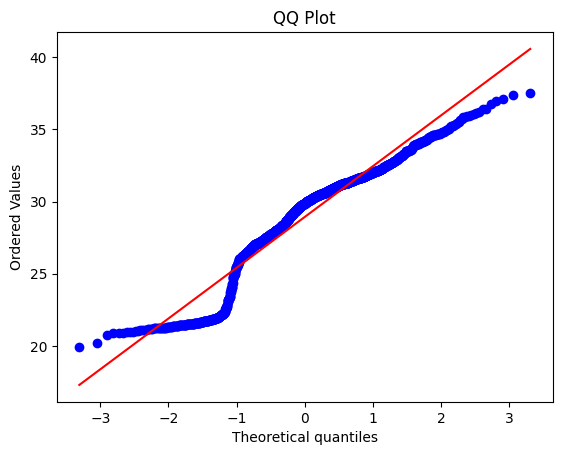

50.04011374366058


In [18]:
# Разбиваем на тренировочный и тестовый
from sklearn.model_selection import train_test_split

x, y = df.drop(columns="bmi"), df["bmi"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3
)

# Используем модель
result = mat_lr.predict(x_test)

# Измеряем ошибку
scs.probplot(result, dist='norm', plot=plt)
plt.title('QQ Plot')
plt.show()
print(mean_squared_error(y_test, result))

##### Ошибка почти не выросла

Но ситуация может быть лучше, если убрать переобучение путём гребневой регуляции

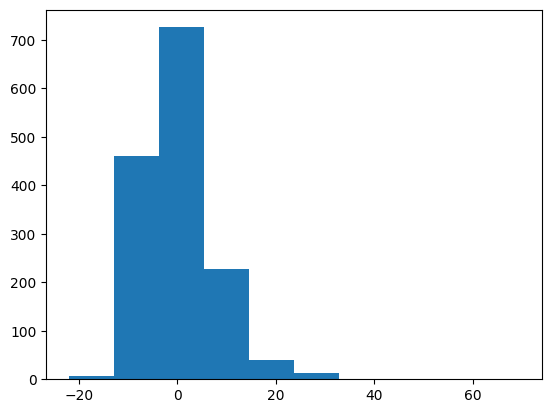

In [19]:
residual = y_test - result
plt.hist(residual)
plt.show()

## Линейная регрессия с гребневой регуляризацией

Реализация также обучается на своей ошибке с использованием градиентного спуска и имеет несколько гиперпараметров

In [20]:
class RidgeRegression() :
    
    def __init__( self, learning_rate, iterations, l2_penalty ) :
        # Гиперпараметры — скорость градиентного спуска, итерации, штраф регуляризации
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.l2_penalty = l2_penalty
        
    def fit( self, X, Y ) :
        if (len(X.shape) < 2):
            self.m, self.n = X.shape[0], 1
        else:
            self.m, self.n = X.shape
        
        self.W = np.zeros(self.n)
        
        self.b = 0        
        self.X = X        
        self.Y = Y
        
        # Стандартизация значений через среднее арифметическое и стандартное отклонение
        self.X_mean = X.mean(axis=0)
        self.X_std = X.std(axis=0)
        X_scaled = (X - self.X_mean) / self.X_std
        X_scaled.iloc[:, 0] = 1

        # То же самое для целевой выборки
        self.Y_mean = Y.mean()
        self.Y_std = Y.std()
        Y_scaled = (Y - self.Y_mean) / self.Y_std

        for i in range( self.iterations ) :            
            Y_pred = self.predict( self.X ) # Предсказываем
            
            error = Y_pred - Y_scaled       # Вычисляем ошибку
            dW = (X_scaled.T.dot(error) / self.m) + self.l2_penalty * self.W    # Вычисляем веса на основе ошибки и штрафа регуляризации Тихонова
                
            self.W -= self.learning_rate * dW   # Применяем веса
            db = - np.sum( self.Y - Y_pred )
            
            self.W = self.W - self.learning_rate * dW    
            self.b = self.b - self.learning_rate * db        

        return self
    
    def predict( self, X ) :    
        return X.dot( self.W ) + self.b

In [21]:
r_lr = RidgeRegression(iterations=100, learning_rate=0.0001, l2_penalty=1)
r_lr.fit(x_train, y_train)

result = r_lr.predict(x_test)

60.38385239917934


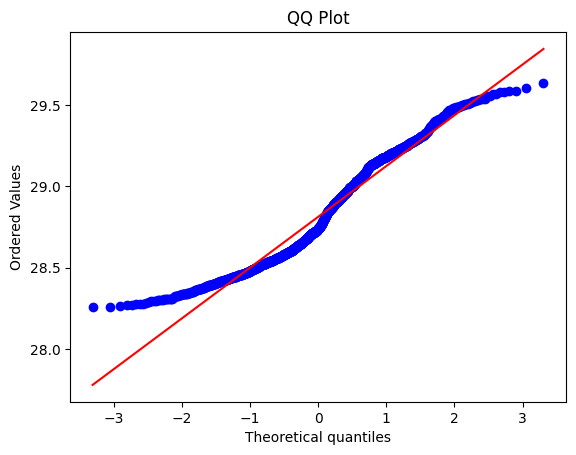

In [22]:
print(mean_squared_error(y_test, result))
scs.probplot(result, dist='norm', plot=plt)
plt.title('QQ Plot')
plt.show()

##### Оба конца графика квантилей выше прямой главного тренда — модель склонна к False Positive

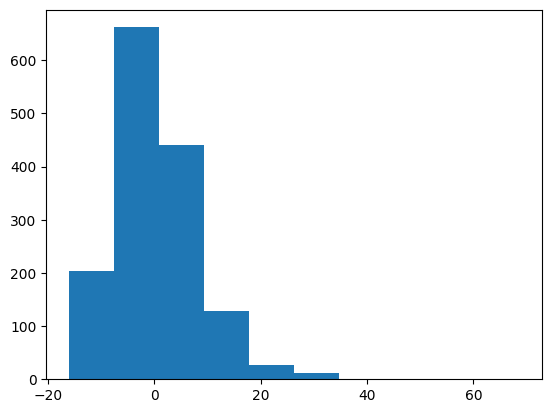

In [23]:
residual = y_test - result
plt.hist(residual)
plt.show()

##### Модель более склонна к False Positive, но показывает хорошую сходимость и очень маленькую ошибку

## Линейная классификация

Задача состоит в предсказании факта инсульта на основе признаков. Для задачи нужно взять другой признак ("stroke") и конвертировать его в ±1

In [24]:
df["stroke"] = df["stroke"].map({0: -1, 1: 1})
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,0,0,0,228.69,36.6,0,1
2,0,80.0,0,1,0,0,1,105.92,32.5,1,1
3,1,49.0,0,0,0,0,0,171.23,34.4,2,1
4,1,79.0,1,0,0,1,1,174.12,24.0,1,1
5,0,81.0,0,0,0,0,0,186.21,29.0,0,1


In [25]:
x, y = df.drop(columns="stroke"), df["stroke"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3
)

In [26]:
import numpy as np
from typing import Tuple, Optional
from enum import Enum

class EmpiricalRisk(Enum):
    HINGE = "hinge"         # SVM loss
    LOGISTIC = "logistic"   # Logistic regression loss
    PERCEPTRON = "perceptron"  # Perceptron loss
    EXPONENTIAL = "exponential"  # AdaBoost loss
    SQUARED_HINGE = "squared_hinge"  # L2-SVM loss

class FlexLinearClassifier:
    def __init__(self, 
                 loss_type: str = "logistic",
                 learning_rate: float = 0.01,
                 l1_ratio: float = 0.5,
                 alpha: float = 0.0001,
                 max_iter: int = 1000,
                 tol: float = 1e-4,
                 offset: float = 1.0,
                 momentum: float = 0.9,         # Инерция
                 nesterov: bool = False,        # Инерция Нестерова вкл/выкл
                 adaptive_lr: bool = True,
                 track_interval: int = 50,
                 verbose: bool = False):
        
        self.loss_type = EmpiricalRisk(loss_type)
        self.learning_rate = learning_rate
        self.l1_ratio = l1_ratio
        self.alpha = alpha
        self.max_iter = max_iter
        self.tol = tol
        self.offset = offset
        self.momentum = momentum
        self.nesterov = nesterov
        self.adaptive_lr = adaptive_lr
        self.track_interval = track_interval
        self.verbose = verbose
        
        self.weights = None
        self.bias = 0
        self.velocity = None    # Для рассчёта инерции
        self.train_loss_history = []
        self.val_loss_history = []
        self.tracking_iterations = []
        
    def _check_fit(self, X: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        
        X = np.asarray(X)
        y = np.asarray(y).ravel()

        if self.momentum > 0 and self.velocity is None:
            self.velocity = np.zeros(X.shape[1] + 1)
            
        return X, y
    
    def _empirical_risk(self, z: np.ndarray, y: np.ndarray) -> np.ndarray:
        if self.loss_type == EmpiricalRisk.HINGE:
            # max(0, offset - z)
            losses = np.maximum(0, self.offset - z)
            
        elif self.loss_type == EmpiricalRisk.SQUARED_HINGE:
            # max(0, offset - z)^2
            losses = np.maximum(0, self.offset - z) ** 2
            
        elif self.loss_type == EmpiricalRisk.LOGISTIC:
            # log(1 + exp(-z))
            # log(1 + exp(-(z - offset)))
            adjusted_z = z - self.offset
            losses = np.log1p(np.exp(-adjusted_z))
            
        elif self.loss_type == EmpiricalRisk.PERCEPTRON:
            # max(0, -z)
            losses = np.maximum(0, -z)
            
        elif self.loss_type == EmpiricalRisk.EXPONENTIAL:
            # exp(-z)
            adjusted_z = z - self.offset
            losses = np.exp(-adjusted_z)
            
        else:
            raise ValueError(f"Unknown loss type: {self.loss_type}")
            
        return losses
    
    def _empirical_risk_gradient(self, X: np.ndarray, y: np.ndarray, 
                                predictions: np.ndarray) -> Tuple[np.ndarray, float]:
        z = y * predictions  # y*(w·x + b)
        
        if self.loss_type == EmpiricalRisk.HINGE:
            # -y*x if z < offset, else 0
            mask = (z < self.offset).astype(float)
            grad_w = -mask[:, np.newaxis] * (y[:, np.newaxis] * X)
            grad_b = -np.sum(mask * y)
            
        elif self.loss_type == EmpiricalRisk.SQUARED_HINGE:
            # -2*y*x*max(0, offset - z)
            margin = np.maximum(0, self.offset - z)
            grad_w = -2 * margin[:, np.newaxis] * (y[:, np.newaxis] * X)
            grad_b = -2 * np.sum(margin * y)
            
        elif self.loss_type == EmpiricalRisk.LOGISTIC:
            # -y*x / (1 + exp(z - offset))
            adjusted_z = z - self.offset
            sigmoid = 1 / (1 + np.exp(adjusted_z))
            grad_w = -(sigmoid[:, np.newaxis] * (y[:, np.newaxis] * X))
            grad_b = -np.sum(sigmoid * y)
            
        elif self.loss_type == EmpiricalRisk.PERCEPTRON:
            # -y*x if z < 0, else 0
            mask = (z < 0).astype(float)
            grad_w = -mask[:, np.newaxis] * (y[:, np.newaxis] * X)
            grad_b = -np.sum(mask * y)
            
        elif self.loss_type == EmpiricalRisk.EXPONENTIAL:
            # -y*x * exp(-(z - offset))
            adjusted_z = z - self.offset
            exp_term = np.exp(-adjusted_z)
            grad_w = -exp_term[:, np.newaxis] * (y[:, np.newaxis] * X)
            grad_b = -np.sum(exp_term * y)
            
        n_samples = X.shape[0]
        grad_w = np.mean(grad_w, axis=0)
        grad_b = grad_b / n_samples
        
        return grad_w, grad_b
    
    def _elastic_net_gradient(self, weights: np.ndarray) -> np.ndarray:
        l1_grad = self.alpha * self.l1_ratio * np.sign(weights)
        l2_grad = self.alpha * (1 - self.l1_ratio) * weights
        return l1_grad + l2_grad
    
    def _adaptive_learning_rate(self, iteration: int, 
                               initial_lr: float) -> float:
        if not self.adaptive_lr:
            return initial_lr
            
        # Инкрементальное затухание функции
        decay = 1.0 / (1.0 + 0.01 * iteration)
        
        if iteration > 0 and iteration % 100 == 0:
            decay = 0.5
        
        # Затухание по экспоненте
        # decay = np.exp(-0.001 * iteration)
        
        return initial_lr * decay
    
    def _proximal_operator(self, weights: np.ndarray, step_size: float) -> np.ndarray:
        if self.l1_ratio == 0:
            return weights
            
        # L1 штраф
        threshold = self.alpha * self.l1_ratio * step_size
        weights_prox = np.sign(weights) * np.maximum(
            np.abs(weights) - threshold, 0)
        
        # L2 штраф
        weights_prox /= (1 + self.alpha * (1 - self.l1_ratio) * step_size)
        
        return weights_prox
    
    # Высчитывание ошибки через указанные эмпирические риски
    def _compute_total_loss(self, X, y_binary):
        predictions = X.dot(self.weights) + self.bias
        z = y_binary * predictions
        
        if self.loss_type == EmpiricalRisk.HINGE:
            empirical = np.maximum(0, self.offset - z).mean()
        elif self.loss_type == EmpiricalRisk.LOGISTIC:
            adjusted_z = np.clip(z - self.offset, -50, 50)
            empirical = np.log1p(np.exp(-adjusted_z)).mean()
        elif self.loss_type == EmpiricalRisk.SQUARED_HINGE:
            empirical = (np.maximum(0, self.offset - z) ** 2).mean()
        
        # Подсчёт штрафа регуляризации
        l1_loss = np.linalg.norm(self.weights, 1)
        l2_loss = 0.5 * np.linalg.norm(self.weights, 2) ** 2
        reg_loss = self.alpha * (self.l1_ratio * l1_loss + 
                               (1 - self.l1_ratio) * l2_loss)
        
        return empirical + reg_loss
    
    def fit(self, X: np.ndarray, y: np.ndarray, 
            sample_weight: Optional[np.ndarray] = None, X_val=None, y_val=None) -> 'FlexLinearClassifier':

        X, y_ = self._check_fit(X, y)
        n_samples, n_features = X.shape
        
        if self.weights is None:
            self.weights = np.random.randn(n_features) * 0.01
            
        if self.momentum > 0:
            self.velocity = np.zeros(n_features + 1)
        
        if sample_weight is None:
            sample_weight = np.ones(n_samples)
        sample_weight = sample_weight / np.sum(sample_weight)
        
        for iteration in range(self.max_iter):
            if iteration % self.track_interval == 0:
                self.tracking_iterations.append(iteration)

                train_loss = self._compute_total_loss(X, y)
                self.train_loss_history.append(train_loss)

                if X_val is not None and y_val is not None:
                    val_loss = self._compute_total_loss(X_val, y_val)
                    self.val_loss_history.append(val_loss)
                
            # Ускорение сходимости инерцией Нестерова
            if self.nesterov and self.momentum > 0:
                weights_ahead = self.weights + self.momentum * self.velocity[:-1]
                bias_ahead = self.bias + self.momentum * self.velocity[-1]
                predictions = X.dot(weights_ahead) + bias_ahead
            else:
                predictions = X.dot(self.weights) + self.bias
            
            grad_w, grad_b = self._empirical_risk_gradient(X, y_, predictions)
            
            grad_w *= np.mean(sample_weight)
            grad_b *= np.mean(sample_weight)
            
            reg_grad = self._elastic_net_gradient(self.weights)
            
            total_grad_w = grad_w + reg_grad
            total_grad = np.append(total_grad_w, grad_b)
            
            current_lr = self._adaptive_learning_rate(iteration, self.learning_rate)
            
            if self.momentum > 0:
                self.velocity = self.momentum * self.velocity - current_lr * total_grad
                update = self.velocity
            else:
                update = -current_lr * total_grad
            
            self.weights += update[:-1]
            self.bias += update[-1]
            
            if self.l1_ratio > 0:
                self.weights = self._proximal_operator(self.weights, current_lr)
            
            z = y_ * (X.dot(self.weights) + self.bias)
            empirical_loss = np.mean(self._empirical_risk(z, y_) * sample_weight)
            
            l1_loss = np.linalg.norm(self.weights, 1)
            l2_loss = 0.5 * np.linalg.norm(self.weights, 2) ** 2
            reg_loss = self.alpha * (self.l1_ratio * l1_loss + 
                                   (1 - self.l1_ratio) * l2_loss)
            
            total_loss = empirical_loss + reg_loss
            # self.val_loss_history.append(total_loss)
            
            # Проверка сходимости
            if iteration > 0 and abs(self.val_loss_history[-1] - total_loss) < self.tol:
                if self.verbose:
                    print(f"Converged at iteration {iteration}")
                break
            
            # Progress reporting
            if self.verbose and iteration % 100 == 0:
                accuracy = self.score(X, y)
                print(f"Iter {iteration}: Loss={total_loss:.4f}, "
                      f"Acc={accuracy:.4f}, LR={current_lr:.6f}")
        
        return self
    
    # Предсказание на основе классификации с округлением принадлежности либо к 1 либо к 0
    def predict(self, X: np.ndarray) -> np.ndarray:
        scores = self.decision_function(X)
        return (scores >= 0).astype(int)
    
    def decision_function(self, X: np.ndarray) -> np.ndarray:
        return X.dot(self.weights) + self.bias

MSE: 1.0


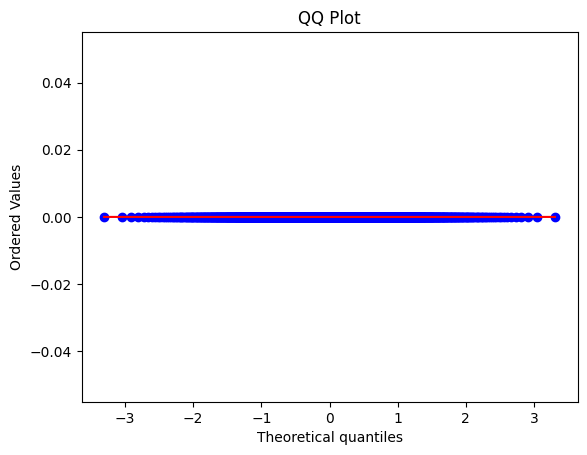

In [27]:
model_hinge = FlexLinearClassifier(
    loss_type="hinge",
    learning_rate=0.01,
    l1_ratio=0.0,
    alpha=0.001,
    offset=1.0,  
    momentum=0.0,
    adaptive_lr=False
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.5
)
model_hinge.fit(x_train, y_train, X_val=x_val, y_val=y_val)
result = model_hinge.predict(x_test)

print(f"MSE: {mean_squared_error(y_test, result)}")
scs.probplot(result, dist='norm', plot=plt)
plt.title('QQ Plot')
plt.show()

MSE: 1.0


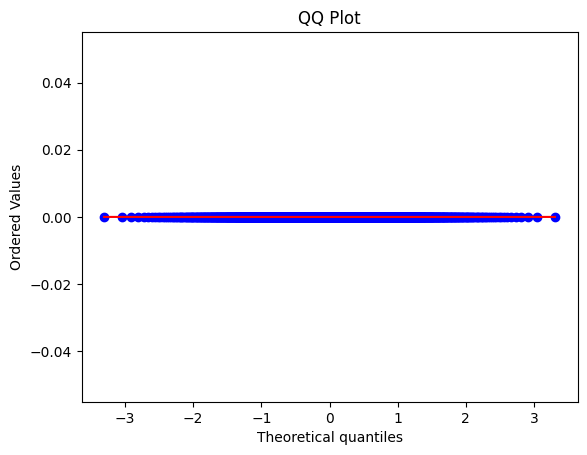

In [28]:
model_logistic = FlexLinearClassifier(
    loss_type="logistic",
    learning_rate=0.1,
    l1_ratio=0.3,
    alpha=0.01,
    offset=1.0,  
    momentum=0.9,
    adaptive_lr=True
)
model_logistic.fit(x_train, y_train, X_val=x_val, y_val=y_val)
result = model_logistic.predict(x_test)

print(f"MSE: {mean_squared_error(y_test, result)}")
scs.probplot(result, dist='norm', plot=plt)
plt.title('QQ Plot')
plt.show()

In [29]:
def plot_multiple_learning_curves(curves_data, title: str = "График обучения") -> plt.Figure:
    """
    Параметры:
    -----------
    curves_data: Список словарей с параметрами
        'name': str
        'iterations': list[int]
        'train_losses': list[float]
        'val_losses': list[float]
        'color':  str (опционально)
        'linestyle': str (опционально)
    title: Название
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(curves_data)))
    
    for idx, data in enumerate(curves_data):
        color = data.get('color', colors[idx])
        linestyle = data.get('linestyle', '-')
        
        ax1.plot(data['iterations'], data['train_losses'],
                color=color, linestyle=linestyle, linewidth=2,
                label=data['name'])
    
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Losses')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    for idx, data in enumerate(curves_data):
        if 'val_losses' in data:
            color = data.get('color', colors[idx])
            linestyle = data.get('linestyle', '-')
            
            ax2.plot(data['iterations'], data['val_losses'],
                    color=color, linestyle=linestyle, linewidth=2,
                    label=data['name'])
    
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Loss')
    ax2.set_title('Validation Losses')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    return fig

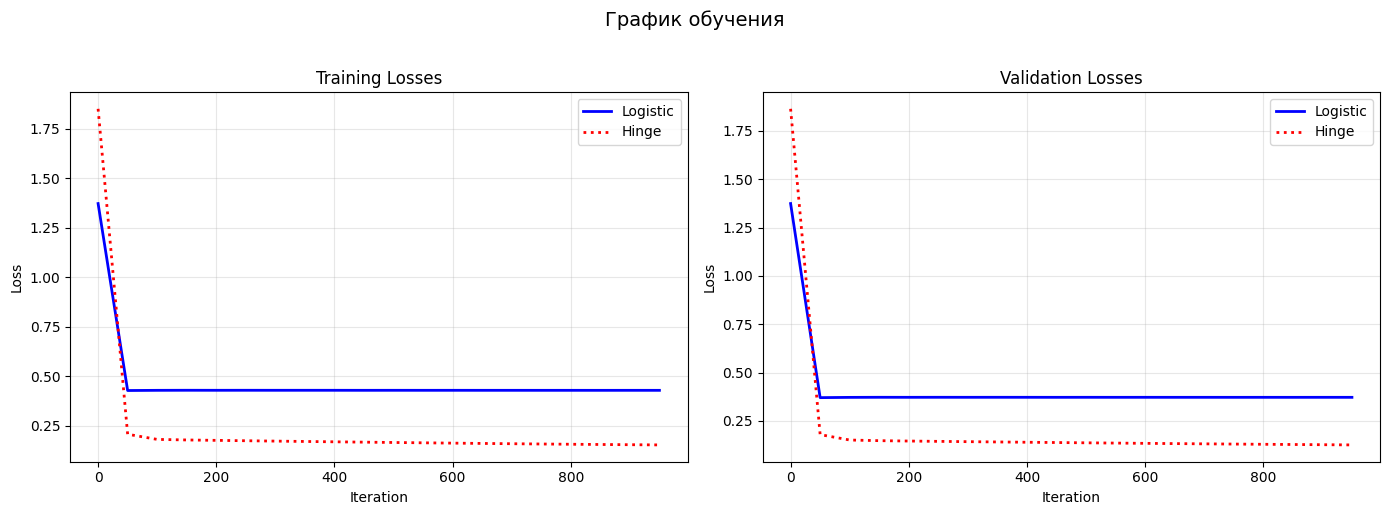

In [30]:
curves_data = [
        {
            'name': 'Logistic',
            'iterations': model_logistic.tracking_iterations,
            'train_losses': model_logistic.train_loss_history,
            'val_losses': model_logistic.val_loss_history[:20],
            'color': 'blue'
        },
        {
            'name': 'Hinge',
            'iterations': model_hinge.tracking_iterations,
            'train_losses': model_hinge.train_loss_history,
            'val_losses': model_hinge.val_loss_history[:20],
            'color': 'red',
            'linestyle': ':'
        }
    ]
    
fig2 = plot_multiple_learning_curves(curves_data)
plt.show()

#### Hinge начинает с бОльшей ошибкой, по сравнению с логистической регрессией, но по ходу обучения быстро минимизирует её даже ниже, чем логистическая регрессия